In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('/Users/sahariasarder/Downloads/Diwali Sales Data.csv', encoding='latin1')


In [3]:
df.shape

(11251, 15)

In [4]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)


In [7]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [10]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [11]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


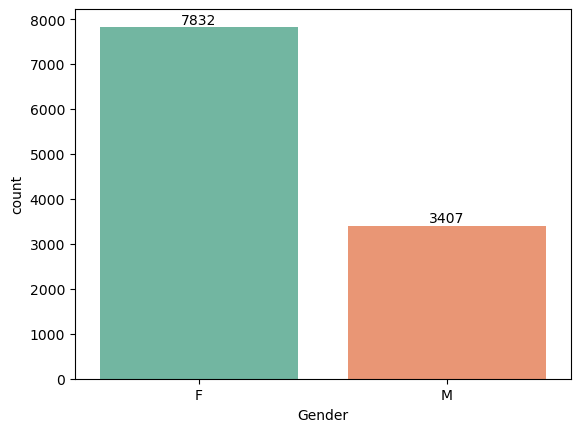

In [12]:
ax = sns.countplot(x='Gender', data=df, hue='Gender', legend=False, palette='Set2')

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

   

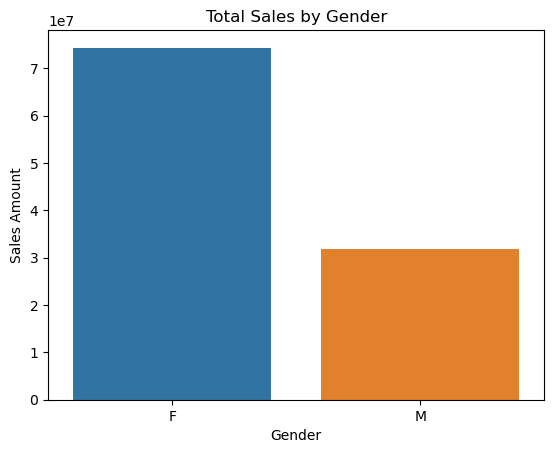

In [13]:
sales_gen = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)


sns.barplot(x='Gender', y='Amount', data=sales_gen, hue='Gender', dodge=False, legend=False)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales Amount")
plt.show()


From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men

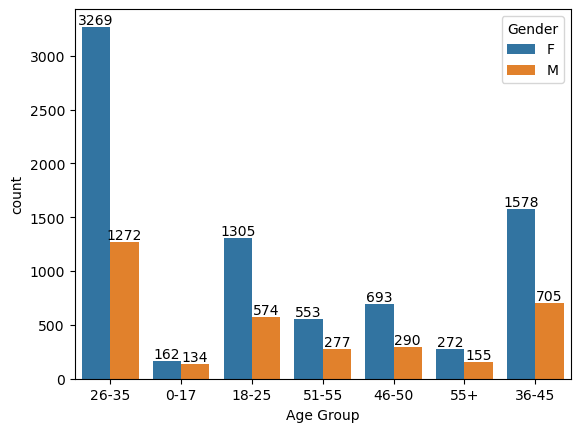

In [14]:
ax = sns.countplot(data=df, x='Age Group', hue='Gender')

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()



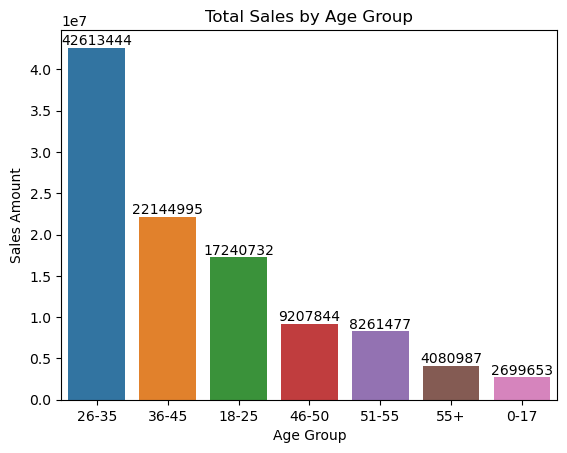

In [15]:
sales_age = df.groupby('Age Group', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)


ax = sns.barplot(x='Age Group', y='Amount', data=sales_age, hue='Age Group', dodge=False, legend=False)
[ax.bar_label(bars, fmt='%.0f') for bars in ax.containers]

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales Amount")
plt.show()

From above graphs we can see that most of the buyers are of age group between 26-35 yrs female

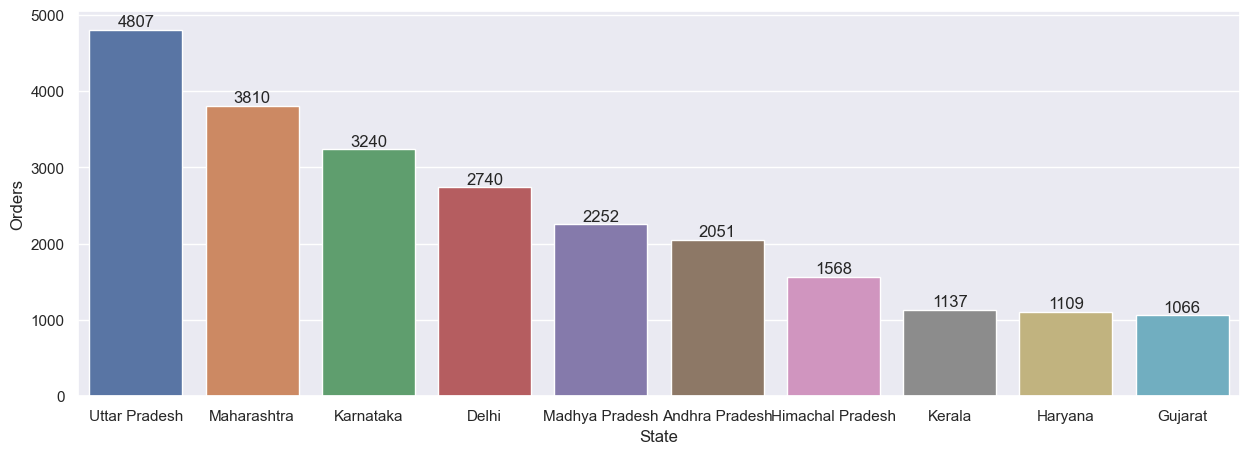

In [16]:
sales_state = df.groupby('State', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})


ax = sns.barplot(x='State', y='Orders', data=sales_state, hue='State', dodge=False, legend=False)


for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.show()

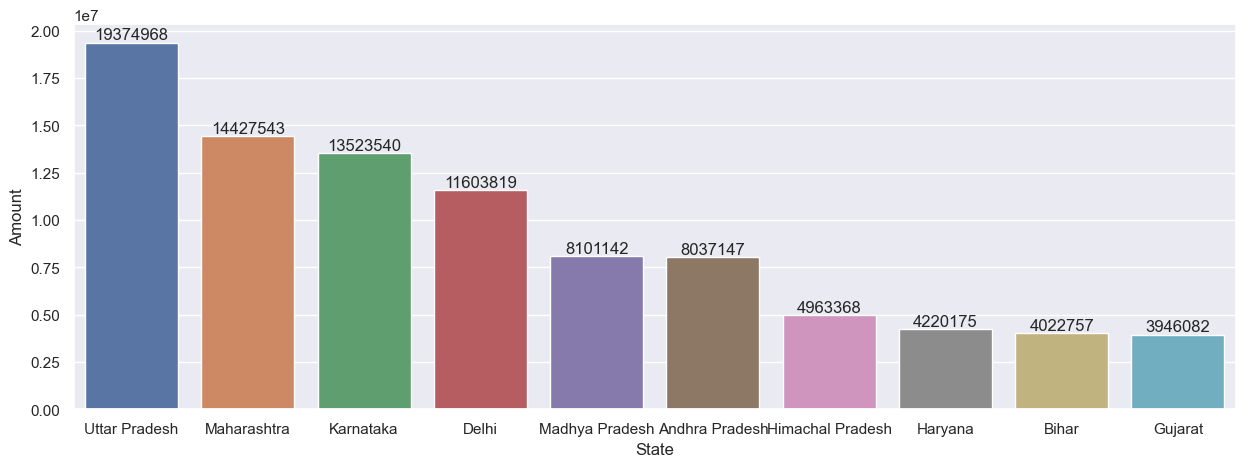

In [17]:

sales_state = df.groupby('State', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})


ax = sns.barplot(x='State', y='Amount', data=sales_state, hue='State', dodge=False, legend=False)


for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.show()

From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively

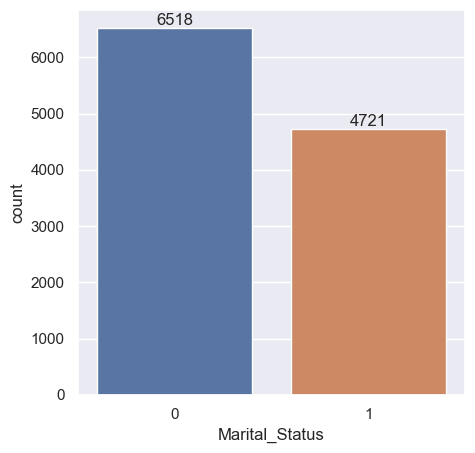

In [18]:
sns.set(rc={'figure.figsize':(5,5)})


ax = sns.countplot(data=df, x='Marital_Status', hue='Marital_Status', dodge=False, legend=False)

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

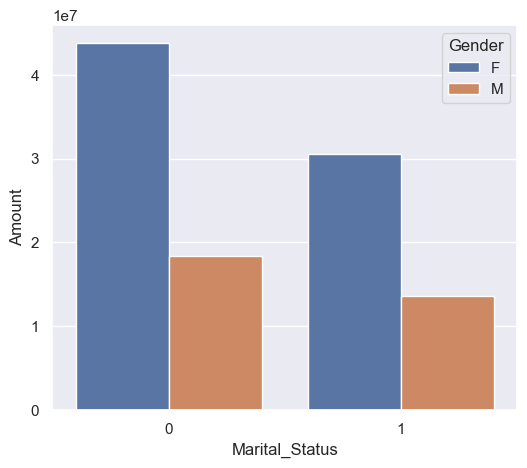

In [19]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')
plt.show()

From above graphs we can see that most of the buyers are married (women) and they have high purchasing power

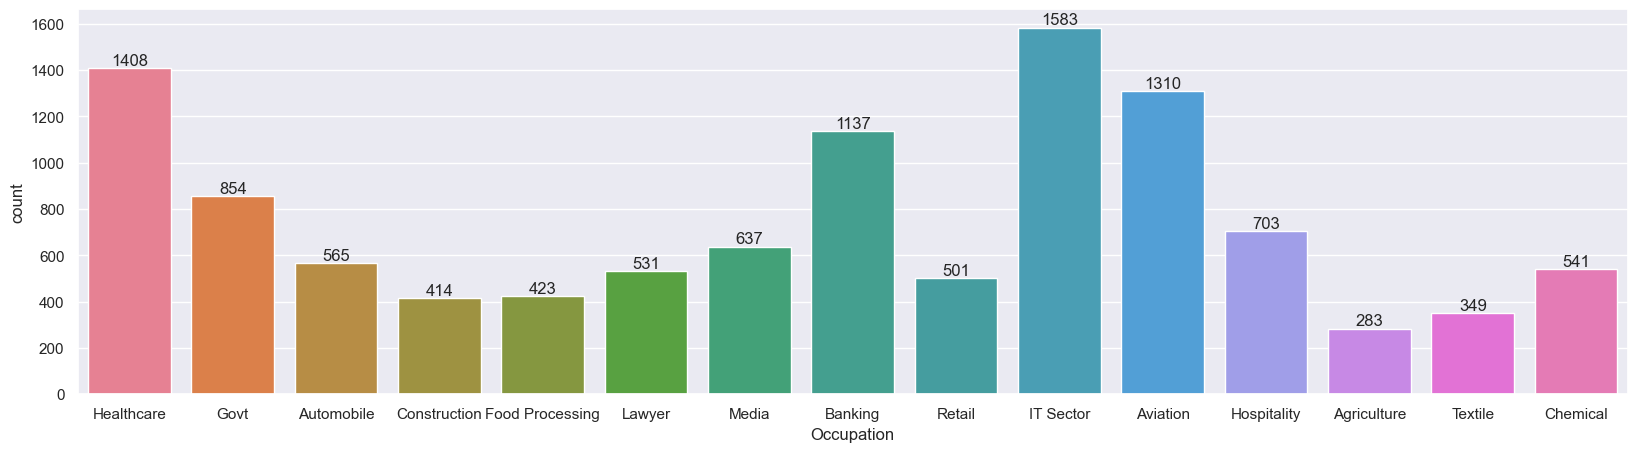

In [20]:
sns.set(rc={'figure.figsize':(20,5)})

ax = sns.countplot(data=df, x='Occupation', hue='Occupation', dodge=False, legend=False)
[ax.bar_label(bars) for bars in ax.containers]

plt.show()

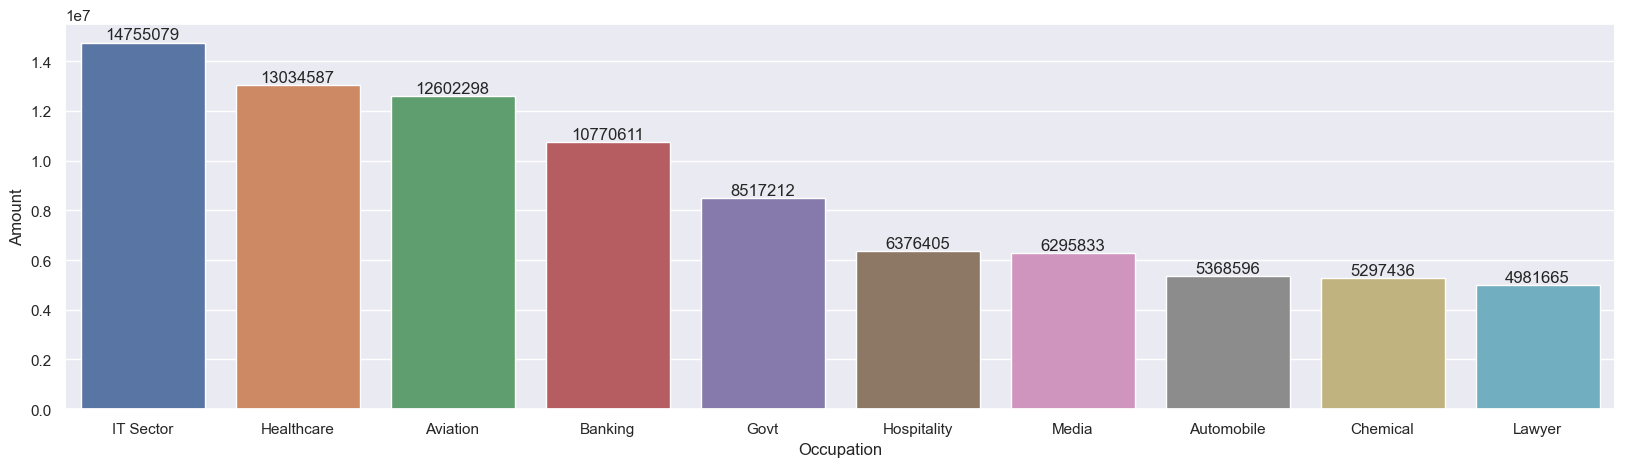

In [21]:
sales_state = df.groupby('Occupation', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
ax = sns.barplot(data=sales_state, x='Occupation', y='Amount', hue='Occupation', dodge=False, legend=False)
[ax.bar_label(bars, fmt='%.0f') for bars in ax.containers]

plt.show()

From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector

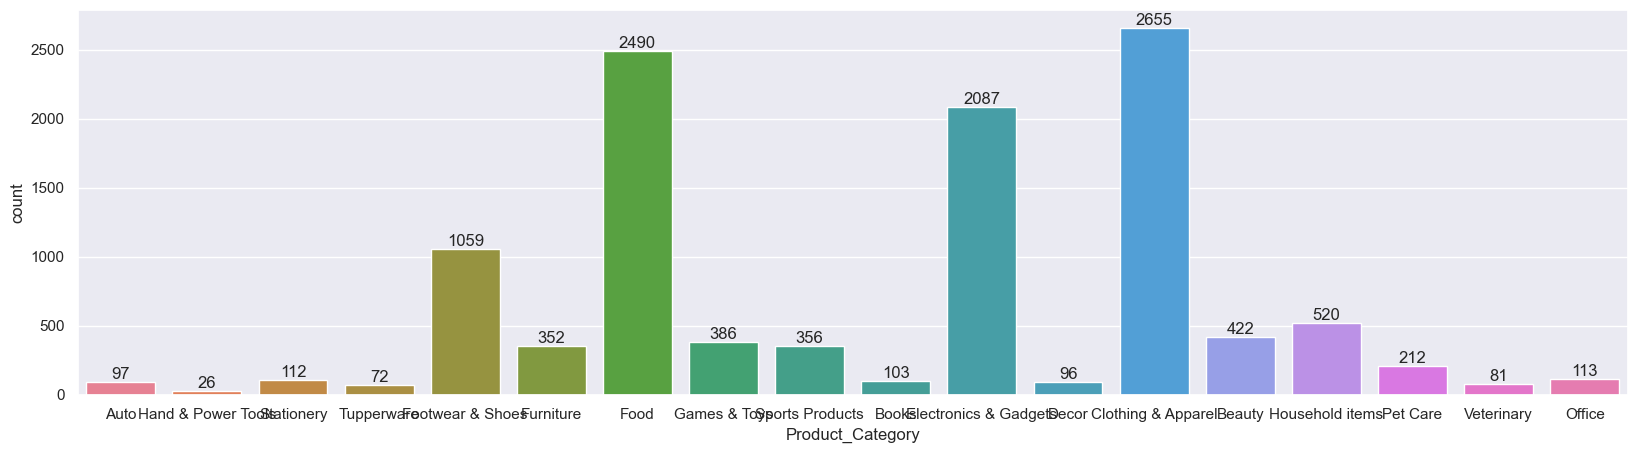

In [22]:
sns.set(rc={'figure.figsize':(20,5)})

ax = sns.countplot(data=df, x='Product_Category', hue='Product_Category', dodge=False, legend=False)
[ax.bar_label(bars) for bars in ax.containers]

plt.show()

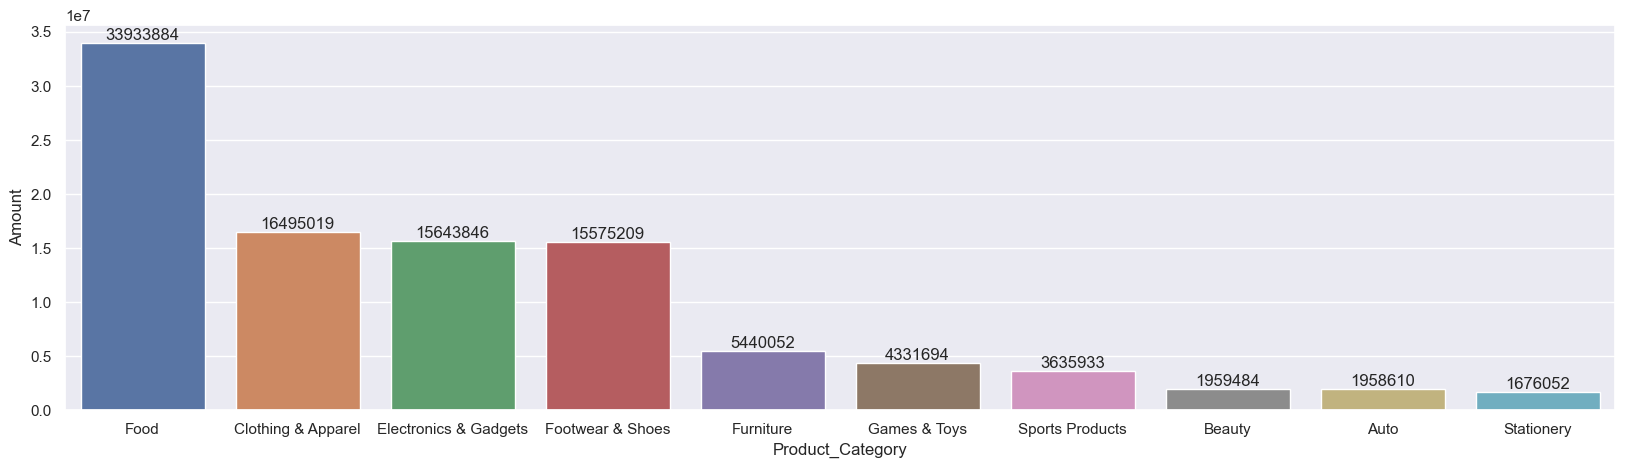

In [23]:

sales_state = df.groupby('Product_Category', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})


ax = sns.barplot(data=sales_state, x='Product_Category', y='Amount', hue='Product_Category', dodge=False, legend=False)
[ax.bar_label(bars, fmt='%.0f') for bars in ax.containers]

plt.show()

From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category

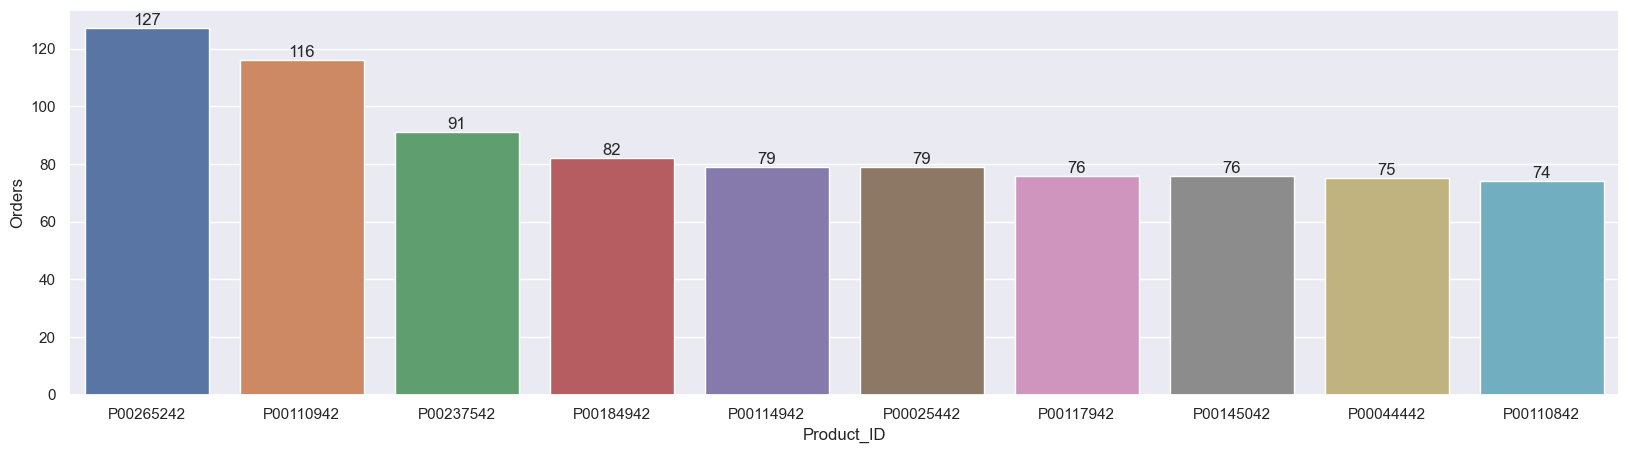

In [24]:
sales_state = df.groupby('Product_ID', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})

ax = sns.barplot(data=sales_state, x='Product_ID', y='Orders', hue='Product_ID', dodge=False, legend=False)
[ax.bar_label(bars, fmt='%.0f') for bars in ax.containers]
plt.show()

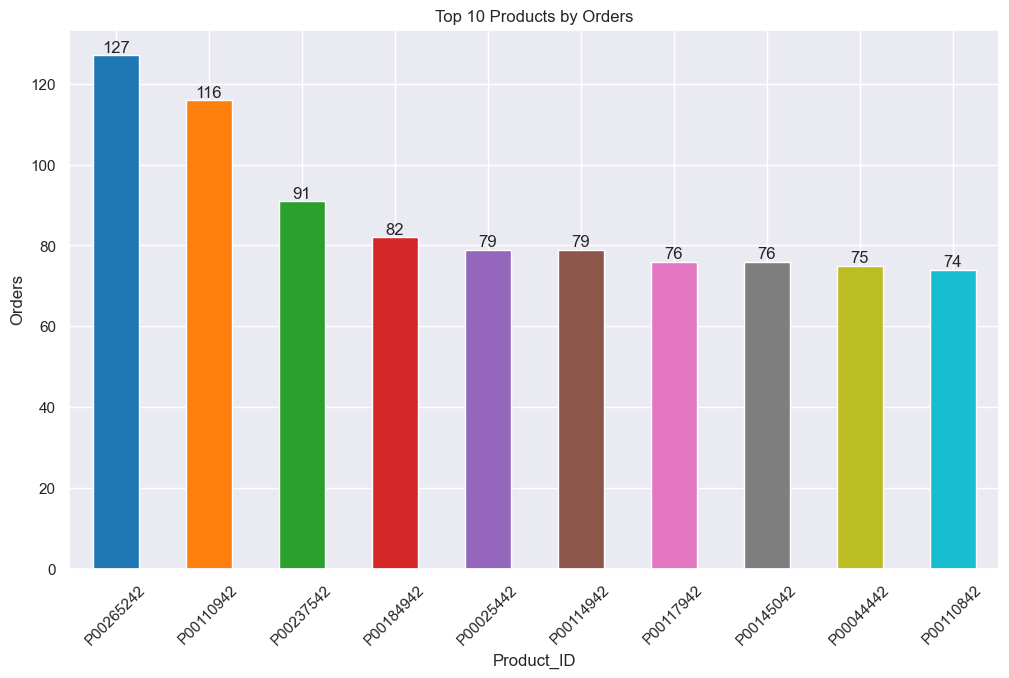

In [25]:
top_products = df.groupby('Product_ID')['Orders'].sum().nlargest(10)

ax = top_products.plot(kind='bar', figsize=(12,7), color=plt.cm.tab10.colors)
[ax.text(i, v, str(v), ha='center', va='bottom') for i, v in enumerate(top_products.values)]

plt.title("Top 10 Products by Orders")
plt.xlabel("Product_ID")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()
